# 02 · Curación de `bronze` a `silver`

- **Proyecto:** Detección de Residuos Urbanos · Computer Vision · UNI 2026-I
- **Autor:** Jairzinho Santos

`silver` es la capa donde vive toda la decisión de curación. Tres principios:

1. **Marca, no borra.** Ninguna imagen ni anotación desaparece: las exclusiones se
   registran como banderas con su motivo, para poder defender cada una con datos.
2. **Alternativas en paralelo, no decisiones únicas.** Donde el EDA dejó una decisión
   abierta se materializan las dos variantes y la comparación se resuelve con
   resultados, no por preferencia. Primera aplicación: la taxonomía multi-clase de
   TACO existe en variante **A (6 materiales, vidrio incluido como marginal)** y
   **B (5 materiales, vidrio excluido)**.
3. **Splits congelados y verificables.** El split queda en un CSV versionado con
   `group_id` anti-fuga, y esta notebook se autoverifica con aserciones duras antes
   de exportar.

### Insumos y salidas

| Entrada | Salida |
|---|---|
| `bronze/<ds>/annotations/*.json` (fuente canónica) | `silver/coco/<ds>.json` — COCO canónico con banderas |
| `data/_eda/imagenes.parquet` (hashes, grupos visuales, dims reales) | `silver/taxonomia.json` — 2 niveles, 2 variantes |
| Hallazgos H1–H5 de la auditoría (cap. 2 del README) | `silver/splits.csv` — 4 esquemas congelados |
| | `silver/_manifest.json` — conteos y hashes |

### Índice

| Parte | Contenido |
|---|---|
| 1 | Carga canónica desde bronze + unión con el escaneo del EDA |
| 2 | Correcciones C1–C5 (los defectos auditados, con evidencia) |
| 3 | Taxonomía de dos niveles · variantes A/B comparadas |
| 4 | Splits: TACO group-aware · RoLID doble esquema · UAVVaste oficial |
| 5 | Batería de validaciones (aserciones duras) |
| 6 | Exportación y manifiesto |

## Parte 0 · Configuración

In [1]:
import sys, subprocess
for _pkg in ("pyarrow", "matplotlib"):
    try:
        __import__(_pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=False)

import json, csv, hashlib, datetime, collections
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
from IPython.display import display

# ── Rutas ────────────────────────────────────────────────────────────────────
_cwd        = Path.cwd()
CODE_DIR    = _cwd.parent if _cwd.name == "notebooks" else _cwd
DATA_BRONZE = CODE_DIR / "data" / "bronze"
EDA_DIR     = CODE_DIR / "data" / "_eda"
SILVER      = CODE_DIR / "data" / "silver"
FIG_DIR     = CODE_DIR / "reports" / "figuras_silver"
for d in (SILVER / "coco", FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEMILLA   = 42
OBJETIVO  = {"train": 0.70, "val": 0.15, "test": 0.15}   # fracción de anotaciones

# ── Sistema visual (idéntico al del EDA) ─────────────────────────────────────
SUPERFICIE = "#fcfcfb"; TINTA_1 = "#1a1a19"; TINTA_2 = "#52514e"; TINTA_3 = "#8a8a80"
REJILLA = "#e6e5e0"
PAL = {"taco": "#2a78d6", "rolid11k": "#eb6834", "uavvaste": "#1baf7a"}
COL_SPLIT = {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a"}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 170,
    "figure.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "axes.facecolor": SUPERFICIE, "axes.edgecolor": REJILLA, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": REJILLA, "grid.linewidth": 1.0,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": TINTA_1,
    "axes.titlepad": 10, "axes.labelsize": 9, "axes.labelcolor": TINTA_2,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.fontsize": 8, "legend.frameon": False, "legend.labelcolor": TINTA_2,
    "font.family": "sans-serif", "font.size": 9,
})


def titulo(txt, ancho=96):
    print("\n" + "═" * ancho); print(txt); print("═" * ancho)


def tabla(df, maxfilas=60):
    with pd.option_context("display.max_rows", maxfilas, "display.width", 200,
                           "display.max_columns", 50, "display.float_format", "{:,.2f}".format):
        display(df)


def nota(txt):
    print(txt.strip())


def mostrar(fig, nombre=None):
    try:
        fig.tight_layout()
    except Exception:
        pass
    if nombre:
        fig.savefig(FIG_DIR / "{}.png".format(nombre), bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    display(fig)
    plt.close(fig)


print("CODE_DIR :", CODE_DIR)
print("SILVER   :", SILVER)
print("semilla  :", SEMILLA, "· objetivo de split:", OBJETIVO)

CODE_DIR : /Volumes/JS-MAIN/Personal/Education/UNI/AI Master/Semesters & Class/Semester 3/Computer Vision/final-project/code
SILVER   : /Volumes/JS-MAIN/Personal/Education/UNI/AI Master/Semesters & Class/Semester 3/Computer Vision/final-project/code/data/silver
semilla  : 42 · objetivo de split: {'train': 0.7, 'val': 0.15, 'test': 0.15}


## Parte 1 · Carga canónica

Las anotaciones se releen **directamente de bronze** (fuente canónica), no del parquet del
EDA: así esta notebook no depende de qué versión del EDA se ejecutó. Del parquet se toma
solo lo que el EDA calculó sobre el pixel: hashes, grupos visuales de casi-duplicados y
dimensiones reales del archivo (para detectar la rotación EXIF pendiente, H2).

Identidad (H1): `clave` = ruta relativa completa (conserva `batch_N/` en TACO) y
`uid` = `dataset::clave`, único y estable.

In [2]:
FUENTES = {
    "taco":     [(None,  "taco/annotations/annotations.json")],
    "rolid11k": [("train", "rolid11k/annotations/training.json"),
                 ("val",   "rolid11k/annotations/validation.json"),
                 ("test",  "rolid11k/annotations/testing.json")],
    "uavvaste": [(None,  "uavvaste/annotations/annotations.json")],
}

filas_img, filas_ann = [], []
for ds, fuentes in FUENTES.items():
    for split_orig, rel in fuentes:
        d = json.load(open(DATA_BRONZE / rel))
        cats = {c["id"]: c["name"] for c in d.get("categories", [])}
        sups = {c["id"]: c.get("supercategory", "") for c in d.get("categories", [])}
        for i in d["images"]:
            clave = i["file_name"]
            filas_img.append({
                "dataset": ds, "clave": clave, "uid": ds + "::" + clave,
                "split_original": split_orig, "id_coco": i["id"],
                "width": i.get("width"), "height": i.get("height"),
            })
        idx = {x["id"]: x for x in d["images"]}
        for a in d["annotations"]:
            info = idx.get(a["image_id"])
            if info is None:
                continue
            x, y, w, h = (list(a["bbox"]) + [0, 0, 0, 0])[:4]
            filas_ann.append({
                "dataset": ds, "uid": ds + "::" + info["file_name"],
                "split_original": split_orig, "ann_id_coco": a["id"],
                "categoria": cats.get(a["category_id"], "?"),
                "supercategoria": sups.get(a["category_id"], ""),
                "x": x, "y": y, "w": w, "h": h,
                "area": a.get("area"), "iscrowd": a.get("iscrowd", 0),
                "tiene_poligono": bool(a.get("segmentation")),
            })

img = pd.DataFrame(filas_img)
ann = pd.DataFrame(filas_ann)

# ── Unión con el escaneo del EDA ─────────────────────────────────────────────
# many_to_one y no one_to_one: la imagen duplicada val/test de RoLID (H5) todavía
# está presente en este punto — C1 la corrige en la parte siguiente.
scan = pd.read_parquet(EDA_DIR / "imagenes.parquet")
scan = scan[scan["dataset"].isin(FUENTES)][
    ["dataset", "clave", "md5", "phash", "grupo_visual", "ancho", "alto", "nitidez"]]
img = img.merge(scan, on=["dataset", "clave"], how="left", validate="many_to_one")

# H2: rotación EXIF pendiente = el archivo crudo tiene las dims intercambiadas
img["exif_girada"] = (img["ancho"] == img["height"]) & (img["alto"] == img["width"]) \
                     & (img["ancho"] != img["width"])

titulo("CARGA CANÓNICA")
res = img.groupby("dataset").agg(
    imagenes=("uid", "size"), sin_escaneo=("md5", lambda s: int(s.isna().sum())),
    exif_giradas=("exif_girada", "sum"))
res["anotaciones"] = ann.groupby("dataset").size()
tabla(res)

ESPERADO = {"taco": (1500, 4784), "rolid11k": (11565, 20927), "uavvaste": (772, 3718)}
for ds, (ni, na) in ESPERADO.items():
    assert len(img[img["dataset"] == ds]) == ni, ds + ": conteo de imágenes no coincide"
    assert len(ann[ann["dataset"] == ds]) == na, ds + ": conteo de anotaciones no coincide"
assert img["uid"].is_unique or img.groupby("uid").size().max() == 2, "uid duplicado inesperado"
print("\nConteos contra bronze: exactos (RoLID incluye aún la imagen duplicada val/test, se corrige en C1).")


════════════════════════════════════════════════════════════════════════════════════════════════
CARGA CANÓNICA
════════════════════════════════════════════════════════════════════════════════════════════════


,imagenes,sin_escaneo,exif_giradas,anotaciones
dataset,,,,
rolid11k,11565,0,0,20927
taco,1500,0,560,4784
uavvaste,772,0,0,3718



Conteos contra bronze: exactos (RoLID incluye aún la imagen duplicada val/test, se corrige en C1).


## Parte 2 · Correcciones C1-C5

Los cinco defectos auditados en el capítulo 2 del README, aplicados con evidencia impresa.
Ninguna corrección borra datos: C1 retira una fila duplicada de un split (la imagen sigue en
test) y el resto son banderas o metadatos.

In [3]:
titulo("C1 · RoLID: imagen presente en validation Y test")

DUP = "20220606234554_000167_Trim_1_frame1168.jpg"
m_dup = (img["dataset"] == "rolid11k") & (img["clave"] == DUP)
print("filas de la imagen duplicada:", int(m_dup.sum()), "(en:",
      sorted(img.loc[m_dup, "split_original"]), ")")

# se conserva la fila de test (comparabilidad con los baselines publicados) y se
# retira la de validation; sus anotaciones de validation se retiran con ella
img["c1_retirada"] = m_dup & (img["split_original"] == "val")
ann["c1_retirada"] = (ann["dataset"] == "rolid11k") & (ann["uid"] == "rolid11k::" + DUP) \
                     & (ann["split_original"] == "val")
img = img[~img["c1_retirada"]].drop(columns=["c1_retirada"]).reset_index(drop=True)
ann = ann[~ann["c1_retirada"]].drop(columns=["c1_retirada"]).reset_index(drop=True)
assert img["uid"].is_unique, "tras C1 el uid debe ser único"
print("tras C1: la imagen queda solo en test · uid ahora único en las {:,} imágenes".format(len(img)))

titulo("C2 · RoLID: categoría fantasma 'None'")
n_none = int((ann["categoria"] == "None").sum())
print("anotaciones con categoría 'None':", n_none, "(el placeholder del exportador VIA no tenía usos)")
ann = ann[ann["categoria"] != "None"].reset_index(drop=True)

titulo("C3 · TACO: identidad por ruta completa + registro EXIF")
print("clave = ruta con batch_N/ aplicada desde la carga (H1).")
print("imágenes con rotación EXIF pendiente registrada:",
      int(img.loc[img["dataset"] == "taco", "exif_girada"].sum()),
      "de", int((img["dataset"] == "taco").sum()),
      "· el pixel se corrige recién al materializar gold")

titulo("C4 · TACO: bbox degenerada")
ann["aspecto"] = np.where(ann["h"] > 0, ann["w"] / ann["h"], np.nan)
ann["flag_geometria"] = (ann["aspecto"] > 20) | (ann["aspecto"] < 0.05) \
                        | (ann["w"] <= 0) | (ann["h"] <= 0)
deg = ann[ann["flag_geometria"]]
tabla(deg[["dataset", "uid", "categoria", "x", "y", "w", "h", "aspecto"]])
print("marcadas flag_geometria =", len(deg), "· quedan en silver; gold las excluye")

titulo("C5 · Duplicados exactos por MD5")
dup_md5 = img[img["md5"].notna()].groupby(["dataset", "md5"]).filter(lambda g: len(g) > 1)
img["flag_duplicado_md5"] = False
for (_, _), g in dup_md5.groupby(["dataset", "md5"]):
    perdedores = g.sort_values("clave").iloc[1:].index      # se conserva la primera por orden estable
    img.loc[perdedores, "flag_duplicado_md5"] = True
print("grupos de duplicados exactos:", dup_md5.groupby(["dataset", "md5"]).ngroups,
      "· imágenes marcadas flag_duplicado_md5:", int(img["flag_duplicado_md5"].sum()))
if len(dup_md5):
    tabla(dup_md5[["dataset", "clave", "md5"]].sort_values(["dataset", "md5"]).head(12))
nota("""
Los duplicados exactos comparten pHash, así que caen en el mismo grupo visual: el split
por grupos ya impide que un par idéntico cruce splits. La bandera solo evita contarlos
dos veces al entrenar.""")


════════════════════════════════════════════════════════════════════════════════════════════════
C1 · RoLID: imagen presente en validation Y test
════════════════════════════════════════════════════════════════════════════════════════════════
filas de la imagen duplicada: 2 (en: ['test', 'val'] )
tras C1: la imagen queda solo en test · uid ahora único en las 13,836 imágenes

════════════════════════════════════════════════════════════════════════════════════════════════
C2 · RoLID: categoría fantasma 'None'
════════════════════════════════════════════════════════════════════════════════════════════════
anotaciones con categoría 'None': 0 (el placeholder del exportador VIA no tenía usos)

════════════════════════════════════════════════════════════════════════════════════════════════
C3 · TACO: identidad por ruta completa + registro EXIF
════════════════════════════════════════════════════════════════════════════════════════════════
clave = ruta con batch_N/ aplicada desde la carga (H1

,dataset,uid,categoria,x,y,w,h,aspecto
2129,taco,taco::batch_15/000060.jpg,Plastic straw,724.00,785.00,39.00,897.00,0.04


marcadas flag_geometria = 1 · quedan en silver; gold las excluye

════════════════════════════════════════════════════════════════════════════════════════════════
C5 · Duplicados exactos por MD5
════════════════════════════════════════════════════════════════════════════════════════════════
grupos de duplicados exactos: 0 · imágenes marcadas flag_duplicado_md5: 0
Los duplicados exactos comparten pHash, así que caen en el mismo grupo visual: el split
por grupos ya impide que un par idéntico cruce splits. La bandera solo evita contarlos
dos veces al entrenar.


## Parte 3 · Taxonomía de dos niveles, con variantes A/B

**Nivel 1 - `litter`** (1 clase): común a los tres datasets. Es el nivel que habilita la
matriz cross-domain y donde `Unlabeled litter` sí participa (es basura, aunque de material
desconocido).

**Nivel 2 - materiales** (solo TACO): agrupamiento de las 60 clases por material, que es el
criterio operativo real (define la corriente de reciclaje). Decisiones de plegado, con motivo:

| Grupo del EDA | Destino | Motivo |
|---|---|---|
| espuma (140 anns) | `plastico_rigido` | el poliestireno expandido es un plástico; 21 instancias en test no sostienen clase propia |
| otros (46) | excluida del nivel 2 | cuerda, comida, zapato, batería: no son un material, plegarlas a cualquiera sería falso |
| sin_etiquetar (517) | excluida del nivel 2 | no es material sino ausencia de etiqueta; en nivel 1 sí cuenta |
| **vidrio (254)** | **variante A: clase propia · variante B: excluida** | 38 instancias proyectadas en test: justo bajo el umbral de 50. Se materializan ambas y el entrenamiento decide |

La comparación A/B se arrastra hasta el final: gold exporta ambas y el capítulo de modelado
reporta las dos columnas.


════════════════════════════════════════════════════════════════════════════════════════════════
NIVEL 2 · VARIANTE A (6 clases) contra VARIANTE B (5 clases)
════════════════════════════════════════════════════════════════════════════════════════════════


,A_anotaciones,B_anotaciones,A_test_proy,B_test_proy
plastico_rigido,1398,"1,398.00",210.00,210.00
plastico_flexible,854,854.00,128.00,128.00
cigarrillo,667,667.00,100.00,100.00
metal,550,550.00,82.00,82.00
papel_carton,498,498.00,75.00,75.00
vidrio,254,NaN,38.00,NaN


cobertura del nivel 2: A = 4,221 anns (88.2%) · B = 3,967 anns (82.9%)


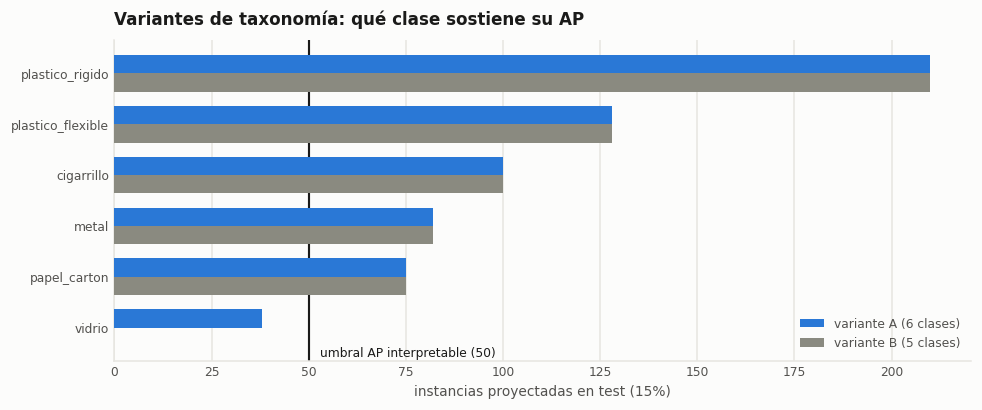

La única diferencia entre variantes es vidrio: en A entra con 38 instancias proyectadas
(marginal, bajo el umbral de 50) y en B sale. El resto de clases es idéntico, así que la
comparación de entrenamiento aísla exactamente el efecto de incluir una clase escasa.


In [4]:
MATERIAL_BASE = {
    "plastico_flexible": ["Plastic film", "Other plastic wrapper", "Single-use carrier bag",
                          "Crisp packet", "Garbage bag", "Six pack rings", "Polypropylene bag",
                          "Plastic glooves"],
    "plastico_rigido":   ["Clear plastic bottle", "Other plastic bottle", "Plastic bottle cap",
                          "Disposable plastic cup", "Other plastic cup", "Plastic straw",
                          "Plastic lid", "Disposable food container", "Spread tub", "Tupperware",
                          "Other plastic container", "Plastic utensils", "Other plastic",
                          "Squeezable tube",
                          # plegado de espuma (poliestireno = plástico)
                          "Styrofoam piece", "Foam cup", "Foam food container"],
    "metal":             ["Drink can", "Food Can", "Aerosol", "Metal bottle cap", "Pop tab",
                          "Aluminium foil", "Scrap metal", "Metal lid", "Aluminium blister pack"],
    "papel_carton":      ["Other carton", "Corrugated carton", "Drink carton", "Meal carton",
                          "Egg carton", "Toilet tube", "Pizza box", "Normal paper", "Tissues",
                          "Magazine paper", "Wrapping paper", "Paper cup", "Paper straw",
                          "Paper bag", "Plastified paper bag", "Carded blister pack"],
    "vidrio":            ["Glass bottle", "Broken glass", "Glass cup", "Glass jar"],
    "cigarrillo":        ["Cigarette"],
}
EXCLUIDAS_NIVEL2 = ["Rope & strings", "Food waste", "Shoe", "Battery", "Unlabeled litter"]

INV = {c: m for m, cs in MATERIAL_BASE.items() for c in cs}

# cobertura exacta de las 60 clases
taco_cls = set(ann.loc[ann["dataset"] == "taco", "categoria"])
sin_mapear = taco_cls - set(INV) - set(EXCLUIDAS_NIVEL2)
assert not sin_mapear, "clases sin mapear: {}".format(sorted(sin_mapear))

# nivel 1: todo es litter (los tres datasets)
ann["litter"] = True
# nivel 2, variante A (6 clases) y B (5 clases, vidrio fuera)
ann["material_a"] = np.where(ann["dataset"] == "taco",
                             ann["categoria"].map(INV), None)
ann["material_b"] = np.where(ann["material_a"] == "vidrio", None, ann["material_a"])

titulo("NIVEL 2 · VARIANTE A (6 clases) contra VARIANTE B (5 clases)")
taco_ann = ann[ann["dataset"] == "taco"]
cmp = pd.DataFrame({
    "A_anotaciones": taco_ann["material_a"].value_counts(),
    "B_anotaciones": taco_ann["material_b"].value_counts(),
})
cmp["A_test_proy"] = (cmp["A_anotaciones"] * OBJETIVO["test"]).round(0)
cmp["B_test_proy"] = (cmp["B_anotaciones"] * OBJETIVO["test"]).round(0)
cmp = cmp.sort_values("A_anotaciones", ascending=False)
tabla(cmp)
print("cobertura del nivel 2: A = {:,} anns ({:.1f}%) · B = {:,} anns ({:.1f}%)".format(
    int(cmp["A_anotaciones"].sum()), cmp["A_anotaciones"].sum() / len(taco_ann) * 100,
    int(cmp["B_anotaciones"].sum()), cmp["B_anotaciones"].sum() / len(taco_ann) * 100))

fig, ax = plt.subplots(figsize=(9, 3.8))
y = np.arange(len(cmp)); h = 0.36
ax.barh(y - h / 2, cmp["A_test_proy"], h, color=PAL["taco"], label="variante A (6 clases)", zorder=3)
ax.barh(y + h / 2, cmp["B_test_proy"].fillna(0), h, color=TINTA_3,
        label="variante B (5 clases)", zorder=3)
ax.axvline(50, color=TINTA_1, lw=1.4)
ax.annotate("umbral AP interpretable (50)", xy=(50, len(cmp) - 0.5), xytext=(53, len(cmp) - 0.5),
            fontsize=8, color=TINTA_1, va="center")
ax.set_yticks(y); ax.set_yticklabels(cmp.index); ax.invert_yaxis()
ax.set_xlabel("instancias proyectadas en test (15%)")
ax.set_title("Variantes de taxonomía: qué clase sostiene su AP", loc="left")
ax.grid(axis="x", color=REJILLA); ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
mostrar(fig, "03_variantes_taxonomia")

nota("""
La única diferencia entre variantes es vidrio: en A entra con 38 instancias proyectadas
(marginal, bajo el umbral de 50) y en B sale. El resto de clases es idéntico, así que la
comparación de entrenamiento aísla exactamente el efecto de incluir una clase escasa.""")

## Parte 4 · Splits congelados

Cuatro esquemas, todos con `group_id` como unidad indivisible (ningún grupo cruza splits):

| Esquema | Dataset | Unidad de grupo | Origen |
|---|---|---|---|
| `taco_groupaware` | TACO | grupo visual (pHash del EDA) | propio, estratificado por material, semilla 42 |
| `rolid_oficial` | RoLID | (frames sueltos) | release oficial, con C1 aplicada; **se sabe contaminado** (H4) y se conserva solo por comparabilidad |
| `rolid_por_video` | RoLID | `video_id` (84 videos) | propio: la corrección honesta de H4 |
| `uavvaste_oficial` | UAVVaste | grupo visual (verificación) | archivo oficial del release; la verificación detecta **1 grupo de casi-duplicados cruzando splits (H6)** |

El reparto propio usa **estratificación iterativa por grupos** (Sechidis et al. 2011,
adaptada): siempre se coloca primero la clase más escasa, tomando el grupo que más aporta a
ella y asignándolo al split que más la necesita. Es determinista y sus garantías se
comprueban en la Parte 5 de hecho, esta batería rechazó un primer algoritmo greedy que
dejaba a `cigarrillo` con 15 instancias en test contra ~100 esperadas.

In [5]:
def split_por_grupos(tabla_img, tabla_ann, col_grupo, col_clase=None, objetivo=OBJETIVO):
    """Estratificación iterativa por grupos (Sechidis et al. 2011, adaptada a grupos).

    En cada paso: (1) la clase con menos anotaciones pendientes, (2) el grupo que más
    aporta a esa clase, (3) el split con mayor deseo restante de esa clase (desempates:
    deseo total y orden alfabético). Determinista por construcción: no usa azar.

    Reemplaza a un greedy por déficit escalar que la batería de validaciones rechazó
    (dejaba a cigarrillo con 15 instancias en test contra ~100 esperadas): la evidencia
    de esa falla quedó en el historial y motivó este algoritmo.
    """
    t = tabla_img[["uid", col_grupo]].copy()
    uid2g = dict(zip(t["uid"], t[col_grupo]))
    a = tabla_ann[["uid"] + ([col_clase] if col_clase else [])].copy()
    a["_cls"] = a[col_clase] if col_clase else "obj"
    a = a.dropna(subset=["_cls"])
    clases = sorted(a["_cls"].unique())

    carga = {g: collections.Counter() for g in t[col_grupo].unique()}
    for uid, cls in zip(a["uid"], a["_cls"]):
        g = uid2g.get(uid)
        if g is not None:
            carga[g][cls] += 1

    total = collections.Counter()
    for v in carga.values():
        total.update(v)
    deseado   = {s: {c: objetivo[s] * total[c] for c in clases} for s in objetivo}
    n_img_g   = t.groupby(col_grupo)["uid"].size().to_dict()
    deseo_img = {s: objetivo[s] * len(t) for s in objetivo}

    restante = dict(carga)
    asig = {}
    while restante:
        pend = collections.Counter()
        for v in restante.values():
            pend.update(v)
        activas = [c for c in clases if pend[c] > 0]
        if not activas:
            # grupos sin anotaciones de las clases activas: por déficit de imágenes
            for g in sorted(restante, key=str):
                s = max(objetivo, key=lambda s: (deseo_img[s], s))
                asig[g] = s
                deseo_img[s] -= n_img_g.get(g, 0)
            break
        c_rara = min(activas, key=lambda c: (pend[c], c))
        g = max((g for g in restante if restante[g][c_rara] > 0),
                key=lambda g: (restante[g][c_rara], str(g)))
        s = max(objetivo, key=lambda s: (deseado[s][c_rara],
                                         sum(deseado[s].values()), s))
        asig[g] = s
        for c, n in restante[g].items():
            deseado[s][c] -= n
        deseo_img[s] -= n_img_g.get(g, 0)
        del restante[g]

    return {uid: asig[g] for uid, g in uid2g.items()}


SPLITS = []   # filas: dataset, uid, esquema, split, group_id

# ── 1 · TACO group-aware estratificado ───────────────────────────────────────
titulo("SPLIT taco_groupaware")
t_img = img[img["dataset"] == "taco"]
t_ann = ann[(ann["dataset"] == "taco")]
asig = split_por_grupos(t_img, t_ann.assign(_m=t_ann["material_a"].fillna("resto")),
                        "grupo_visual", "_m")
for row in t_img.itertuples():
    SPLITS.append({"dataset": "taco", "uid": row.uid, "esquema": "taco_groupaware",
                   "split": asig[row.uid], "group_id": row.grupo_visual})
sp = pd.Series({u: s for u, s in asig.items()})
print("imágenes por split:", sp.value_counts().to_dict())

# ── 2 · RoLID oficial (con C1) ───────────────────────────────────────────────
titulo("SPLIT rolid_oficial (contaminado a nivel de video; se conserva por comparabilidad)")
r_img = img[img["dataset"] == "rolid11k"].copy()
r_img["video_id"] = r_img["clave"].str.split("_frame").str[0]
for row in r_img.itertuples():
    SPLITS.append({"dataset": "rolid11k", "uid": row.uid, "esquema": "rolid_oficial",
                   "split": row.split_original, "group_id": row.video_id})
print("imágenes por split:", r_img["split_original"].value_counts().to_dict())

# ── 3 · RoLID por video (la corrección de H4) ────────────────────────────────
titulo("SPLIT rolid_por_video")
r_ann = ann[ann["dataset"] == "rolid11k"]
asig_v = split_por_grupos(r_img, r_ann, "video_id")
for row in r_img.itertuples():
    SPLITS.append({"dataset": "rolid11k", "uid": row.uid, "esquema": "rolid_por_video",
                   "split": asig_v[row.uid], "group_id": row.video_id})
spv = pd.Series({u: s for u, s in asig_v.items()})
print("imágenes por split:", spv.value_counts().to_dict())

# ── 4 · UAVVaste oficial ─────────────────────────────────────────────────────
titulo("SPLIT uavvaste_oficial")
dist = json.load(open(DATA_BRONZE / "uavvaste/annotations/train_val_test_distribution_file.json"))
# el archivo oficial mezcla mayúsculas y minúsculas: correspondencia insensible a caja
mapa_ci = {c.lower(): c for c in img.loc[img["dataset"] == "uavvaste", "clave"]}
u_split = {}
for s, lista in dist.items():
    for nombre in lista:
        real = mapa_ci.get(nombre.lower())
        if real:
            u_split["uavvaste::" + real] = s
u_img = img[img["dataset"] == "uavvaste"]
sin_asignar = [u for u in u_img["uid"] if u not in u_split]
print("cubiertas por el archivo oficial:", len(u_split), "de", len(u_img),
      "· sin asignar:", len(sin_asignar))
assert not sin_asignar, "el split oficial de UAVVaste no cubre todas las imágenes"
for row in u_img.itertuples():
    SPLITS.append({"dataset": "uavvaste", "uid": row.uid, "esquema": "uavvaste_oficial",
                   "split": u_split[row.uid], "group_id": row.grupo_visual})
print("imágenes por split:", pd.Series(u_split).value_counts().to_dict())

# hallazgo H6: el split oficial de UAVVaste también tiene fuga, en miniatura
u_chk = u_img.assign(split=u_img["uid"].map(u_split))
u_multi = u_chk.groupby("grupo_visual")["split"].nunique()
u_cruzados = u_multi[u_multi > 1].index.tolist()
if u_cruzados:
    print("\n[H6] grupos de casi-duplicados que cruzan splits en el split OFICIAL:", len(u_cruzados))
    for g in u_cruzados:
        tabla(u_chk.loc[u_chk["grupo_visual"] == g, ["clave", "split", "phash"]]
              .reset_index(drop=True))
    nota("""
Frames consecutivos del mismo vuelo repartidos entre train y test: el mismo defecto que
RoLID (H4) pero a escala mínima. Se conserva el split oficial por comparabilidad y el
hallazgo queda registrado; con 1 grupo afectado el impacto en métricas es despreciable,
pero confirma el patrón: ningún release revisado parte por escena.""")

splits_df = pd.DataFrame(SPLITS)


════════════════════════════════════════════════════════════════════════════════════════════════
SPLIT taco_groupaware
════════════════════════════════════════════════════════════════════════════════════════════════
imágenes por split: {'train': 988, 'test': 270, 'val': 242}

════════════════════════════════════════════════════════════════════════════════════════════════
SPLIT rolid_oficial (contaminado a nivel de video; se conserva por comparabilidad)
════════════════════════════════════════════════════════════════════════════════════════════════
imágenes por split: {'train': 7990, 'test': 2374, 'val': 1200}

════════════════════════════════════════════════════════════════════════════════════════════════
SPLIT rolid_por_video
════════════════════════════════════════════════════════════════════════════════════════════════
imágenes por split: {'train': 7498, 'test': 2075, 'val': 1991}

════════════════════════════════════════════════════════════════════════════════════════════════
SPLI

,clave,split,phash
0,batch_s01_img_1440.jpg,test,fee2cfcc88cc805c
1,batch_s01_img_1060.jpg,train,fee3cfcc8c4c801c


Frames consecutivos del mismo vuelo repartidos entre train y test: el mismo defecto que
RoLID (H4) pero a escala mínima. Se conserva el split oficial por comparabilidad y el
hallazgo queda registrado; con 1 grupo afectado el impacto en métricas es despreciable,
pero confirma el patrón: ningún release revisado parte por escena.



════════════════════════════════════════════════════════════════════════════════════════════════
COMPARATIVA · rolid_oficial contra rolid_por_video
════════════════════════════════════════════════════════════════════════════════════════════════


split,train,val,test
esquema,,,
rolid_oficial,7990,1200,2374
rolid_por_video,7498,1991,2075


,imgs_test,test_con_video_en_train,pct_fuga
esquema,,,
rolid_oficial,2374,1382,58.20
rolid_por_video,2075,0,0.00


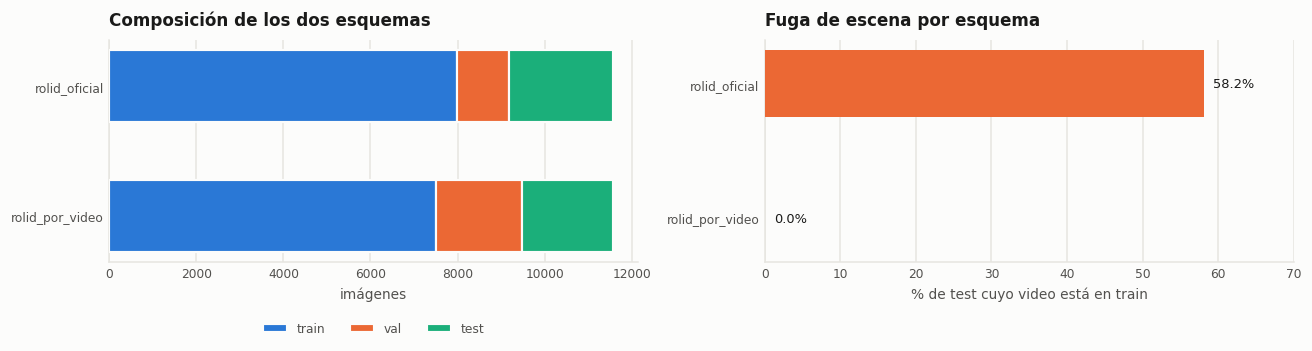

Mismo dataset, mismas imágenes: un esquema con 58% de fuga de escena y otro con cero.
Entrenar el mismo modelo sobre ambos y comparar el mAP de test es el experimento que
cuantifica cuánto infla la fuga los resultados publicados.


In [6]:
titulo("COMPARATIVA · rolid_oficial contra rolid_por_video")

r = splits_df[splits_df["dataset"] == "rolid11k"]
piv = r.pivot_table(index="esquema", columns="split", values="uid", aggfunc="count")
tabla(piv[["train", "val", "test"]])

# fuga por esquema: % de imágenes de test cuyo video aparece en train
filas_fuga = []
for esq, g in r.groupby("esquema"):
    v_train = set(g.loc[g["split"] == "train", "group_id"])
    test = g[g["split"] == "test"]
    n = int(test["group_id"].isin(v_train).sum())
    filas_fuga.append({"esquema": esq, "imgs_test": len(test),
                       "test_con_video_en_train": n,
                       "pct_fuga": round(n / max(len(test), 1) * 100, 1)})
fuga = pd.DataFrame(filas_fuga).set_index("esquema")
tabla(fuga)
assert fuga.loc["rolid_por_video", "test_con_video_en_train"] == 0, \
    "el esquema por video no puede tener fuga"

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
piv2 = piv[["train", "val", "test"]]
y = np.arange(len(piv2))
izq = np.zeros(len(piv2))
for s in ("train", "val", "test"):
    axes[0].barh(y, piv2[s], left=izq, height=0.55, color=COL_SPLIT[s], label=s,
                 zorder=3, edgecolor=SUPERFICIE, linewidth=1.4)
    izq += piv2[s].values
axes[0].set_yticks(y); axes[0].set_yticklabels(piv2.index); axes[0].invert_yaxis()
axes[0].set_xlabel("imágenes"); axes[0].set_title("Composición de los dos esquemas", loc="left")
axes[0].grid(axis="x", color=REJILLA); axes[0].grid(axis="y", visible=False)
axes[0].legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.22))

axes[1].barh([0, 1], fuga["pct_fuga"], height=0.5,
             color=[PAL["rolid11k"], TINTA_3], zorder=3)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(fuga.index); axes[1].invert_yaxis()
axes[1].set_xlabel("% de test cuyo video está en train")
axes[1].set_title("Fuga de escena por esquema", loc="left")
for i, v in enumerate(fuga["pct_fuga"]):
    axes[1].text(v + 1.2, i, "{:.1f}%".format(v), va="center", fontsize=8.5, color=TINTA_1)
axes[1].set_xlim(0, 70)
axes[1].grid(axis="x", color=REJILLA); axes[1].grid(axis="y", visible=False)
mostrar(fig, "04_rolid_esquemas")

nota("""
Mismo dataset, mismas imágenes: un esquema con 58% de fuga de escena y otro con cero.
Entrenar el mismo modelo sobre ambos y comparar el mAP de test es el experimento que
cuantifica cuánto infla la fuga los resultados publicados.""")

## Parte 5 · Batería de validaciones

Aserciones duras: si alguna falla, la notebook se detiene y no se exporta nada.

In [7]:
titulo("VALIDACIONES")

ok = []

# V1 · cobertura exacta: cada esquema cubre todas las imágenes de su dataset una vez
for esq, g in splits_df.groupby("esquema"):
    ds = g["dataset"].iloc[0]
    assert g["uid"].is_unique, esq + ": uid repetido"
    assert len(g) == (img["dataset"] == ds).sum(), esq + ": no cubre todas las imágenes"
    ok.append((esq, "cobertura completa y sin repetidos", len(g)))

# V2 · ningún grupo cruza splits en los esquemas PROPIOS (aserción dura).
# Los esquemas oficiales son contratos externos: sus defectos se reportan (H4, H6),
# no se corrigen aquí, porque su valor es la comparabilidad con lo publicado.
OFICIALES = {"rolid_oficial": "H4", "uavvaste_oficial": "H6"}
for esq, g in splits_df.groupby("esquema"):
    cruzados = g.groupby("group_id")["split"].nunique()
    n_cruzados = int((cruzados > 1).sum())
    if esq in OFICIALES:
        print("  [conocido {}] {}: {} grupo(s) cruzan splits · se conserva por comparabilidad".format(
            OFICIALES[esq], esq, n_cruzados))
    else:
        assert n_cruzados == 0, "{}: {} grupos cruzan splits".format(esq, n_cruzados)
        ok.append((esq, "cero grupos cruzando splits", n_cruzados))

# V3 · proporciones dentro de tolerancia en los esquemas propios.
# El objetivo 70/15/15 está definido sobre ANOTACIONES (es lo que el algoritmo
# estratifica); con grupos indivisibles de tamaño desigual, las imágenes solo
# pueden aproximarse y se reportan como dato informativo.
for esq in ("taco_groupaware", "rolid_por_video"):
    g = splits_df[splits_df["esquema"] == esq]
    ds = g["dataset"].iloc[0]
    a_esq = ann[ann["dataset"] == ds].merge(g[["uid", "split"]], on="uid")
    fr_ann = a_esq["split"].value_counts(normalize=True)
    fr_img = g["split"].value_counts(normalize=True)
    for s, obj in OBJETIVO.items():
        assert abs(fr_ann[s] - obj) < 0.05,             "{}: {} se desvía en anotaciones ({:.3f} vs {:.2f})".format(esq, s, fr_ann[s], obj)
    ok.append((esq, "anotaciones dentro de +-5pp del objetivo",
               {s: round(float(fr_ann[s]), 3) for s in OBJETIVO}))
    print("  [info] {:<18} imágenes por split: {}".format(
        esq, {s: round(float(fr_img[s]), 3) for s in OBJETIVO}))

# V4 · instancias por clase en el test real de TACO (ambas variantes)
g = splits_df[splits_df["esquema"] == "taco_groupaware"][["uid", "split"]]
ta = ann[ann["dataset"] == "taco"].merge(g, on="uid")
test_a = ta[ta["split"] == "test"]["material_a"].value_counts()
test_b = ta[ta["split"] == "test"]["material_b"].value_counts()
comp_test = pd.DataFrame({"A_test_real": test_a, "B_test_real": test_b})
comp_test["proyectado"] = (ta["material_a"].value_counts() * OBJETIVO["test"]).round(0)
tabla(comp_test)
assert (test_b >= 50).all(), "variante B: alguna clase quedó bajo 50 en test"
ok.append(("taco variante B", "todas las clases con 50 o más en test", int(test_b.min())))
print("variante A: mínimo en test = {} (vidrio, marginal declarado)".format(int(test_a.min())))

# V5 · estratificación: la fracción de cada material por split no se desvía en exceso
frac = (ta.dropna(subset=["material_a"]).groupby(["material_a", "split"]).size()
          .groupby(level=0, group_keys=False).apply(lambda s: s / s.sum()).unstack(fill_value=0))
desv = (frac[["train", "val", "test"]] - pd.Series(OBJETIVO)).abs().max().max()
print("desviación máxima de estratificación por material: {:.3f} (tolerancia 0.08)".format(desv))
assert desv < 0.08, "estratificación fuera de tolerancia"
ok.append(("taco_groupaware", "estratificación por material dentro de +-8pp", round(float(desv), 3)))

print("\nRESUMEN")
for esq, msg, dato in ok:
    print("  [ok] {:<22} {} · {}".format(esq, msg, dato))


════════════════════════════════════════════════════════════════════════════════════════════════
VALIDACIONES
════════════════════════════════════════════════════════════════════════════════════════════════
  [conocido H4] rolid_oficial: 22 grupo(s) cruzan splits · se conserva por comparabilidad
  [conocido H6] uavvaste_oficial: 1 grupo(s) cruzan splits · se conserva por comparabilidad
  [info] taco_groupaware    imágenes por split: {'train': 0.659, 'val': 0.161, 'test': 0.18}
  [info] rolid_por_video    imágenes por split: {'train': 0.648, 'val': 0.172, 'test': 0.179}


,A_test_real,B_test_real,proyectado
cigarrillo,100,100.00,100.00
metal,83,83.00,82.00
papel_carton,75,75.00,75.00
plastico_flexible,128,128.00,128.00
plastico_rigido,210,210.00,210.00
vidrio,38,NaN,38.00


variante A: mínimo en test = 38 (vidrio, marginal declarado)
desviación máxima de estratificación por material: 0.001 (tolerancia 0.08)

RESUMEN
  [ok] rolid_oficial          cobertura completa y sin repetidos · 11564
  [ok] rolid_por_video        cobertura completa y sin repetidos · 11564
  [ok] taco_groupaware        cobertura completa y sin repetidos · 1500
  [ok] uavvaste_oficial       cobertura completa y sin repetidos · 772
  [ok] rolid_por_video        cero grupos cruzando splits · 0
  [ok] taco_groupaware        cero grupos cruzando splits · 0
  [ok] taco_groupaware        anotaciones dentro de +-5pp del objetivo · {'train': 0.698, 'val': 0.148, 'test': 0.154}
  [ok] rolid_por_video        anotaciones dentro de +-5pp del objetivo · {'train': 0.7, 'val': 0.15, 'test': 0.15}
  [ok] taco variante B        todas las clases con 50 o más en test · 75
  [ok] taco_groupaware        estratificación por material dentro de +-8pp · 0.001



════════════════════════════════════════════════════════════════════════════════════════════════
DISTRIBUCIÓN FINAL POR SPLIT
════════════════════════════════════════════════════════════════════════════════════════════════


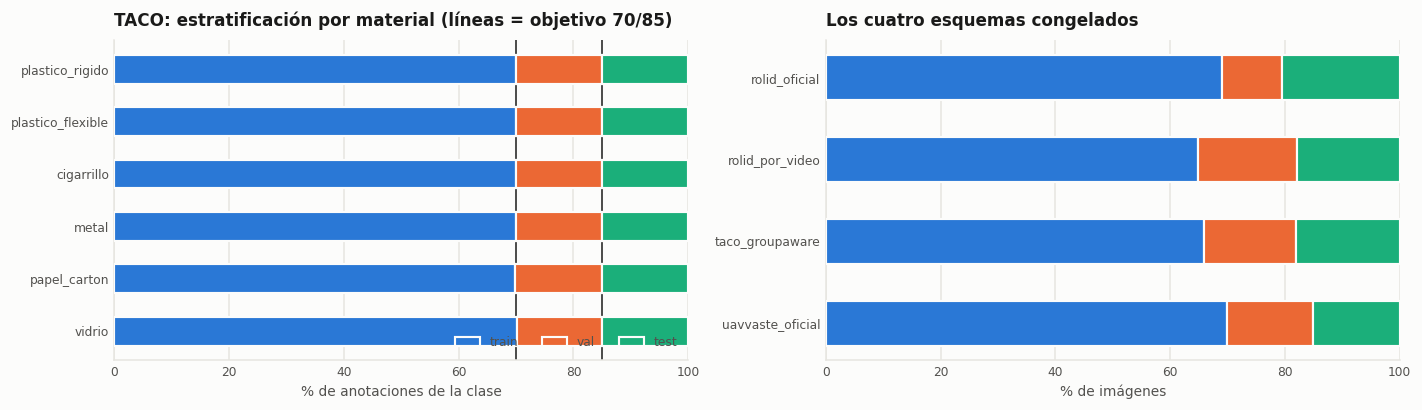

In [8]:
titulo("DISTRIBUCIÓN FINAL POR SPLIT")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

orden_m = comp_test.sort_values("A_test_real", ascending=False).index.tolist()
frac2 = frac.loc[[m for m in orden_m if m in frac.index]]
y = np.arange(len(frac2)); izq = np.zeros(len(frac2))
for s in ("train", "val", "test"):
    axes[0].barh(y, frac2[s] * 100, left=izq, height=0.55, color=COL_SPLIT[s], label=s,
                 zorder=3, edgecolor=SUPERFICIE, linewidth=1.4)
    izq += frac2[s].values * 100
axes[0].axvline(70, color=TINTA_1, lw=1.0); axes[0].axvline(85, color=TINTA_1, lw=1.0)
axes[0].set_yticks(y); axes[0].set_yticklabels(frac2.index); axes[0].invert_yaxis()
axes[0].set_xlim(0, 100); axes[0].set_xlabel("% de anotaciones de la clase")
axes[0].set_title("TACO: estratificación por material (líneas = objetivo 70/85)", loc="left")
axes[0].grid(axis="x", color=REJILLA); axes[0].grid(axis="y", visible=False)
axes[0].legend(ncol=3, loc="lower right")

tam = splits_df.groupby(["esquema", "split"]).size().unstack()[["train", "val", "test"]]
y2 = np.arange(len(tam)); izq = np.zeros(len(tam))
for s in ("train", "val", "test"):
    v = tam[s] / tam.sum(axis=1) * 100
    axes[1].barh(y2, v, left=izq, height=0.55, color=COL_SPLIT[s], label=s,
                 zorder=3, edgecolor=SUPERFICIE, linewidth=1.4)
    izq += v.values
axes[1].set_yticks(y2); axes[1].set_yticklabels(tam.index); axes[1].invert_yaxis()
axes[1].set_xlim(0, 100); axes[1].set_xlabel("% de imágenes")
axes[1].set_title("Los cuatro esquemas congelados", loc="left")
axes[1].grid(axis="x", color=REJILLA); axes[1].grid(axis="y", visible=False)
mostrar(fig, "05_distribucion_splits")

## Parte 6 · Exportación y manifiesto

Formato de salida:

- `silver/coco/<ds>.json` - COCO canónico: imágenes con `uid`, ruta a bronze, dims
  post-EXIF, banderas; anotaciones con las tres columnas de clase (`litter`,
  `material_a`, `material_b`) y sus banderas
- `silver/taxonomia.json` - los dos niveles, las dos variantes y los plegados con motivo
- `silver/splits.csv` - una fila por (uid, esquema): el contrato de todos los experimentos
- `silver/_manifest.json` - conteos, semilla y hash SHA-256 de los artefactos

In [9]:
titulo("EXPORTACIÓN")

# ── COCO canónico por dataset ────────────────────────────────────────────────
for ds in FUENTES:
    di = img[img["dataset"] == ds]
    da = ann[ann["dataset"] == ds]
    salida = {
        "info": {
            "dataset": ds, "capa": "silver",
            "generado": datetime.datetime.now().isoformat(timespec="seconds"),
            "fuente_bronze": str(DATA_BRONZE / ds),
            "correcciones": ["C1", "C2", "C3", "C4", "C5"],
        },
        "images": [
            {"uid": r.uid, "clave": r.clave,
             "ruta_bronze": str(Path(ds) / "images" / r.clave),
             "width": int(r.width), "height": int(r.height),
             "exif_girada": bool(r.exif_girada),
             "group_id": str(r.grupo_visual),
             "flags": (["duplicado_md5"] if r.flag_duplicado_md5 else [])}
            for r in di.itertuples()
        ],
        "annotations": [
            {"uid_img": r.uid, "ann_id_origen": int(r.ann_id_coco),
             "bbox": [float(r.x), float(r.y), float(r.w), float(r.h)],
             "area": float(r.area) if pd.notna(r.area) else None,
             "iscrowd": int(r.iscrowd), "tiene_poligono": bool(r.tiene_poligono),
             "categoria_origen": r.categoria,
             "litter": bool(r.litter),
             "material_a": r.material_a if pd.notna(r.material_a) else None,
             "material_b": r.material_b if pd.notna(r.material_b) else None,
             "flags": (["geometria"] if r.flag_geometria else [])}
            for r in da.itertuples()
        ],
    }
    ruta = SILVER / "coco" / (ds + ".json")
    ruta.write_text(json.dumps(salida, ensure_ascii=False))
    print("  {} -> {:,} imgs · {:,} anns · {:.1f} MB".format(
        ruta.name, len(salida["images"]), len(salida["annotations"]),
        ruta.stat().st_size / 1e6))

# ── Taxonomía ────────────────────────────────────────────────────────────────
taxonomia = {
    "nivel1": {"clases": ["litter"], "datasets": list(FUENTES),
               "nota": "Unlabeled litter participa en este nivel"},
    "nivel2": {
        "dataset": "taco",
        "variante_a": {"clases": sorted(MATERIAL_BASE), "n": len(MATERIAL_BASE),
                       "nota": "vidrio incluido, declarado marginal (38 proyectadas en test)"},
        "variante_b": {"clases": sorted(set(MATERIAL_BASE) - {"vidrio"}), "n": 5,
                       "nota": "vidrio excluido; el resto idéntico a la variante A"},
        "mapeo": MATERIAL_BASE,
        "excluidas": EXCLUIDAS_NIVEL2,
        "plegados": {"espuma": "plastico_rigido (EPS es plástico)",
                     "otros": "excluido (no constituyen un material)",
                     "sin_etiquetar": "excluido del nivel 2, presente en nivel 1"},
    },
}
(SILVER / "taxonomia.json").write_text(json.dumps(taxonomia, indent=2, ensure_ascii=False))
print("  taxonomia.json escrito")

# ── Splits ───────────────────────────────────────────────────────────────────
splits_df = splits_df.sort_values(["dataset", "esquema", "uid"]).reset_index(drop=True)
splits_df.to_csv(SILVER / "splits.csv", index=False)
print("  splits.csv -> {:,} filas · {} esquemas".format(
    len(splits_df), splits_df["esquema"].nunique()))

# ── Manifiesto ───────────────────────────────────────────────────────────────
def _sha(p):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for blk in iter(lambda: f.read(1 << 20), b""):
            h.update(blk)
    return h.hexdigest()

manifest = {
    "generado": datetime.datetime.now().isoformat(timespec="seconds"),
    "semilla": SEMILLA, "objetivo_split": OBJETIVO,
    "imagenes": int(len(img)), "anotaciones": int(len(ann)),
    "esquemas": {e: g["split"].value_counts().to_dict()
                 for e, g in splits_df.groupby("esquema")},
    "flags": {"duplicado_md5": int(img["flag_duplicado_md5"].sum()),
              "geometria": int(ann["flag_geometria"].sum()),
              "exif_girada": int(img["exif_girada"].sum())},
    "sha256": {p.name: _sha(p) for p in
               [SILVER / "splits.csv", SILVER / "taxonomia.json"]
               + sorted((SILVER / "coco").glob("*.json"))},
}
(SILVER / "_manifest.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print("  _manifest.json escrito")

titulo("SILVER COMPLETO")
print("imágenes {:,} · anotaciones {:,} · 4 esquemas de split · 2 variantes de taxonomía".format(
    len(img), len(ann)))
print("""
Lo que hereda gold (notebook 03):
  · silver/coco/*.json      -> qué imagen y qué caja entra a cada experimento
  · silver/splits.csv       -> a qué split va cada imagen segun el esquema del experimento
  · silver/taxonomia.json   -> id de clase por variante (A/B se exportan ambas)
  · flags                   -> gold excluye duplicado_md5 y geometria; aplica exif_girada al pixel""")


════════════════════════════════════════════════════════════════════════════════════════════════
EXPORTACIÓN
════════════════════════════════════════════════════════════════════════════════════════════════
  taco.json -> 1,500 imgs · 4,784 anns · 1.7 MB
  rolid11k.json -> 11,564 imgs · 20,926 anns · 9.2 MB
  uavvaste.json -> 772 imgs · 3,718 anns · 1.1 MB
  taxonomia.json escrito
  splits.csv -> 25,400 filas · 4 esquemas
  _manifest.json escrito

════════════════════════════════════════════════════════════════════════════════════════════════
SILVER COMPLETO
════════════════════════════════════════════════════════════════════════════════════════════════
imágenes 13,836 · anotaciones 29,428 · 4 esquemas de split · 2 variantes de taxonomía

Lo que hereda gold (notebook 03):
  · silver/coco/*.json      -> qué imagen y qué caja entra a cada experimento
  · silver/splits.csv       -> a qué split va cada imagen segun el esquema del experimento
  · silver/taxonomia.json   -> id de clase por v